# Sentiment140 Neural Baseline: GloVe + BiLSTM

This notebook implements the neural baseline for the Sentiment140 pipeline under the unified project structure.

It is designed to:
- load the fixed Sentiment140 splits from `artifacts/sentiment140/splits/`
- train a **binary** sentiment classifier with GloVe + BiLSTM
- save reusable experiment artifacts under the Sentiment140 subfolder
- export publication-ready figures for later thesis writing
- support later construction of a **happiness index** through sentiment probabilities and aggregate sentiment scores

## Why this model matters for the thesis
Compared with TF-IDF + Logistic Regression, the BiLSTM baseline can capture sequential context and word-order information. This makes it useful for analysing whether a stronger neural baseline improves sentiment estimation before moving to transformer models.

## Prerequisite: Download GloVe once
Download `glove.6B.zip` from Stanford and extract `glove.6B.300d.txt`.

Place it at: `./artifacts/glove/glove.6B.300d.txt`

Source: https://nlp.stanford.edu/projects/glove/


## 0. Verify required packages

This section verifies the core packages required for the LSTM experiment. Running it first helps reduce import-related errors and makes the notebook easier to reproduce in a new environment.

In [1]:
import importlib
import subprocess
import sys


def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"✅ {package_name} already installed")
    except ImportError:
        print(f"⬇️ Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("torch", "torch"),
    ("scikit-learn", "sklearn"),
    ("keras-preprocessing", "keras_preprocessing"),
]

for package_name, import_name in required_packages:
    install_if_missing(package_name, import_name)

print(f"Python executable: {sys.executable}")

✅ numpy already installed
✅ pandas already installed
✅ matplotlib already installed
✅ seaborn already installed
✅ torch already installed
✅ scikit-learn already installed
✅ keras-preprocessing already installed
Python executable: d:\Anaconda\envs\happiness-nlp\python.exe


## 1. Setup and unified paths

This section defines the unified project paths, creates the required output folders, and sets the main experiment configuration for the LSTM baseline.

In [2]:
# === 1) Setup & Unified Paths ===
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import classification_report, confusion_matrix

# Compatibility fix for NumPy 2.0+
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

from keras_preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = BASE_DIR / "artifacts"
DATASET_NAME = "sentiment140"
DATASET_ARTIFACT_DIR = ARTIFACT_ROOT / DATASET_NAME

SPLIT_DIR = DATASET_ARTIFACT_DIR / "splits"
PRED_DIR = DATASET_ARTIFACT_DIR / "predictions"
MODEL_DIR = DATASET_ARTIFACT_DIR / "models"
CONFIG_DIR = DATASET_ARTIFACT_DIR / "config"
FIG_DIR = DATASET_ARTIFACT_DIR / "figures"
RESULT_DIR = DATASET_ARTIFACT_DIR / "results"

for folder in [ARTIFACT_ROOT, DATASET_ARTIFACT_DIR, SPLIT_DIR, PRED_DIR, MODEL_DIR, CONFIG_DIR, FIG_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = SPLIT_DIR / "train_60.csv"
VAL_PATH   = SPLIT_DIR / "val_10.csv"
TEST_PATH  = SPLIT_DIR / "test_30.csv"

# Unified resource path
GLOVE_PATH = BASE_DIR / "glove" / "glove.6B.300d.txt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

RANDOM_STATE = 42
MAX_VOCAB = 50_000
MAX_LEN = 50
EMBED_DIM = 300
HIDDEN_DIM = 128
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-3

NEG_TH = 0.40
POS_TH = 0.60

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

sns.set_theme(style="whitegrid")


Using device: cuda


## 2. Load dataset splits

The fixed train, validation, and test splits are loaded from the shared Sentiment140 artifacts folder so that results remain comparable across different models.

In [3]:
# === 2) Load fixed splits ===
train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))
print("Columns:", list(train_df.columns))

required_cols = ["text_clean", "label"]
missing = [col for col in required_cols if col not in train_df.columns]
if missing:
    raise KeyError(f"Missing required columns in split CSV: {missing}. Found: {list(train_df.columns)}")

# Prefer keeping raw text in the split files for cleaner downstream exports.
# If an older split file does not contain `text`, fall back to `text_clean`.
def ensure_export_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "text" not in df.columns:
        df["text"] = df["text_clean"].astype(str)
    return df[["text", "text_clean", "label"]]

train_df = ensure_export_columns(train_df)
val_df   = ensure_export_columns(val_df)
test_df  = ensure_export_columns(test_df)

print("Unified split schema:", list(train_df.columns))


Train / Val / Test sizes: 960000 160000 480000
Columns: ['text', 'text_clean', 'label']
Unified split schema: ['text', 'text_clean', 'label']


## 3. Text preparation

Here the cleaned text is tokenised and padded into fixed-length sequences, which converts each tweet into a numerical input suitable for neural sequence modelling.

In [4]:
# === 3) Tokenization + Padding ===
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text_clean"].astype(str).tolist())

train_seq = tokenizer.texts_to_sequences(train_df["text_clean"].astype(str).tolist())
val_seq   = tokenizer.texts_to_sequences(val_df["text_clean"].astype(str).tolist())
test_seq  = tokenizer.texts_to_sequences(test_df["text_clean"].astype(str).tolist())

X_train = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val   = pad_sequences(val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
X_test  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_df["label"].astype(int).to_numpy()
y_val   = val_df["label"].astype(int).to_numpy()
y_test  = test_df["label"].astype(int).to_numpy()

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print("Vocab size:", vocab_size)
print("X_train shape:", X_train.shape)


Vocab size: 50000
X_train shape: (960000, 50)


## 4. Load pretrained embeddings

This step reads the GloVe vectors and prepares the external word representations that will initialise the embedding layer of the model.

In [5]:
# === 4) Load GloVe vectors ===
if not GLOVE_PATH.exists():
    raise FileNotFoundError(
        f"Missing GloVe file at: {GLOVE_PATH}\n"
        "Download glove.6B.zip from https://nlp.stanford.edu/projects/glove/ and extract glove.6B.300d.txt\n"
        "Then place it under {BASE_DIR}/glove/glove.6B.300d.txt"
    )

embeddings_index = {}
with open(GLOVE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        word = parts[0]
        vec = np.asarray(parts[1:], dtype="float32")
        if vec.shape[0] != EMBED_DIM:
            continue
        embeddings_index[word] = vec

print("Loaded GloVe vectors:", len(embeddings_index))


Loaded GloVe vectors: 400000


## 5. Build the embedding matrix

The tokenizer vocabulary is aligned with the pretrained GloVe vectors. Words not found in GloVe are assigned small random values so the model can still learn from them.

In [6]:
# === 5) Build embedding matrix aligned with tokenizer vocab ===
rng = np.random.default_rng(RANDOM_STATE)
embedding_matrix = rng.normal(0, 0.05, size=(vocab_size, EMBED_DIM)).astype("float32")

hits = 0
for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        hits += 1

print(f"Embedding coverage: {hits}/{vocab_size} = {hits / vocab_size:.2%}")


Embedding coverage: 37836/50000 = 75.67%


## 6. Build datasets and loaders

The processed arrays are wrapped into PyTorch datasets and dataloaders to support efficient mini-batch training and evaluation.

In [7]:
# === 6) Dataset & DataLoaders ===
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val, y_val),     batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TextDataset(X_test, y_test),   batch_size=BATCH_SIZE, shuffle=False)


## 7. Define the LSTM model

A BiLSTM classifier is defined here as the neural baseline. It combines pretrained embeddings with sequence modelling to capture contextual sentiment signals.

In [8]:
# === 7) Define BiLSTM model ===
class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix: np.ndarray, hidden_dim: int = 128, dropout: float = 0.5):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = True

        self.embedding_dropout = nn.Dropout(0.2)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.embedding_dropout(x)
        _, (h_n, _) = self.lstm(x)
        h = torch.cat((h_n[-2], h_n[-1]), dim=1)
        h = self.dropout(h)
        logits = self.fc(h).squeeze(1)
        return logits

model = BiLSTMClassifier(embedding_matrix, hidden_dim=HIDDEN_DIM).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)


BiLSTMClassifier(
  (embedding): Embedding(50000, 300)
  (embedding_dropout): Dropout(p=0.2, inplace=False)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


## 8. Train the model

This section runs the training loop, monitors validation loss, and keeps the best checkpoint for later evaluation.

In [9]:
# === 8) Train loop (with best validation checkpoint and early stopping) ===
def predict_probs(loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            logits = model(Xb)
            pb = torch.sigmoid(logits).cpu().numpy()
            probs.append(pb)
            labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)

history = []
best_val_loss = float("inf")
best_path = MODEL_DIR / "sentiment140_lstm_model_binary.pt"

EARLY_STOPPING_PATIENCE = 2
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for Xb, yb in train_loader:
        Xb = Xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / max(1, len(train_loader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb = Xb.to(device)
            yb = yb.to(device)
            logits = model(Xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()

    val_loss /= max(1, len(val_loader))
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_path)
        print(f"  Saved best checkpoint -> {best_path}")
    else:
        patience_counter += 1
        print(f"  No improvement. Early stopping counter: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print("  Early stopping triggered.")
            break

Epoch 01 | train_loss=0.4078 | val_loss=0.3755
  Saved best checkpoint -> ..\artifacts\sentiment140\models\sentiment140_lstm_model_binary.pt
Epoch 02 | train_loss=0.3562 | val_loss=0.3749
  Saved best checkpoint -> ..\artifacts\sentiment140\models\sentiment140_lstm_model_binary.pt
Epoch 03 | train_loss=0.3280 | val_loss=0.3764
  No improvement. Early stopping counter: 1/2
Epoch 04 | train_loss=0.3038 | val_loss=0.3942
  No improvement. Early stopping counter: 2/2
  Early stopping triggered.


### Training diagnostics

The loss curve is saved as a figure so that the neural baseline can be discussed more clearly in the dissertation. This is useful when comparing optimisation behaviour across TF-IDF, LSTM, and transformer models.


## 9. Save the learning curve

The training history is plotted and exported as a figure so the optimisation process can be reused directly in the dissertation.

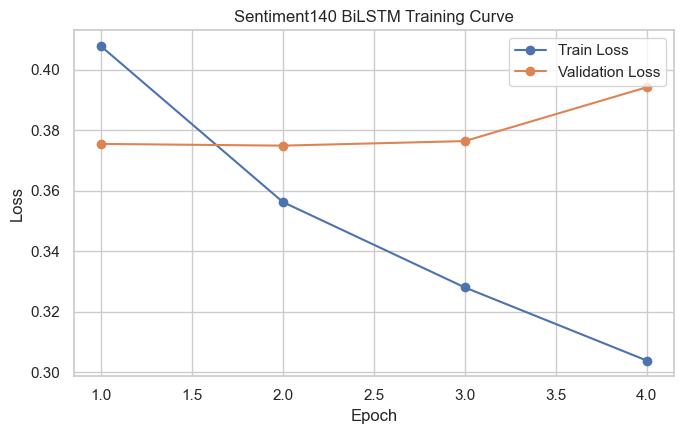

Saved training curve: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\figures\lstm_training_curve.png


In [10]:
# === 9) Save training curve ===
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4.5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentiment140 BiLSTM Training Curve")
plt.legend()
plt.tight_layout()

train_curve_path = FIG_DIR / "lstm_training_curve.png"
plt.savefig(train_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved training curve:", train_curve_path.resolve())


## 10. Evaluate on the test set

The best checkpoint is reloaded and evaluated on the held-out test set. Standard classification metrics and a confusion matrix are generated for reporting.

C:\Users\seventh720\AppData\Local\Temp\ipykernel_10640\1672743381.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_locatio

              precision    recall  f1-score   support

         0.0     0.8361    0.8317    0.8339    240000
         1.0     0.8326    0.8370    0.8348    240000

    accuracy                         0.8343    480000
   macro avg     0.8343    0.8343    0.8343    480000
weighted avg     0.8343    0.8343    0.8343    480000

Confusion matrix:
 [[199606  40394]
 [ 39124 200876]]


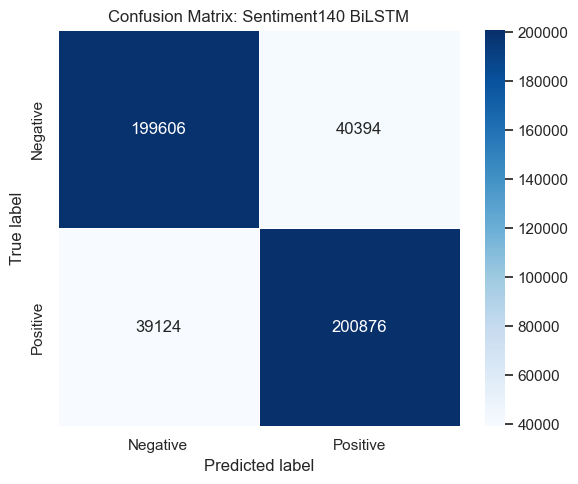

Saved confusion matrix figure: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\figures\lstm_confusion_matrix.png


In [11]:
# === 10) Load best checkpoint & evaluate on test set ===
model.load_state_dict(torch.load(best_path, map_location=device))

test_probs, test_labels = predict_probs(test_loader)
pred_binary = (test_probs >= 0.5).astype(int)

print(classification_report(test_labels, pred_binary, digits=4))

cm = confusion_matrix(test_labels, pred_binary)
print("Confusion matrix:\n", cm)

labels = ["Negative", "Positive"]
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor="white",
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Sentiment140 BiLSTM")
plt.tight_layout()

cm_path = FIG_DIR / "lstm_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure:", cm_path.resolve())


### Neutral mapping and thesis relevance

The classifier is still trained as a binary model, but its positive probability can be converted into a three-way sentiment output through thresholding. This is useful for the thesis because a later **happiness index** can be constructed in at least two ways:

1. **Binary sentiment score**: aggregate positive probabilities or positive/negative predictions over time.
2. **Three-class sentiment score**: treat neutral content as a middle state, which can reduce over-polarised index fluctuations.

This makes the LSTM baseline relevant not only as a classifier, but also as a component for a sentiment-based public wellbeing indicator.


## 11. Map probabilities to three sentiment classes

Binary positive probabilities are converted into negative, neutral, and positive labels through thresholding, which provides a bridge from classification to happiness-index construction.

In [12]:
# === 11) Neutral post-hoc mapping ===
def proba_to_3class(probs: np.ndarray, neg_th: float = 0.4, pos_th: float = 0.6):
    probs = np.asarray(probs, dtype=float)
    out = np.empty(probs.shape[0], dtype=object)
    out[probs <= neg_th] = "NEGATIVE"
    out[probs >= pos_th] = "POSITIVE"
    mid = (probs > neg_th) & (probs < pos_th)
    out[mid] = "NEUTRAL"
    return out

pred_3class = proba_to_3class(test_probs, neg_th=NEG_TH, pos_th=POS_TH)
neutral_rate = (pred_3class == "NEUTRAL").mean()
print(f"Neutral rate on test: {neutral_rate:.4f} (NEG_TH={NEG_TH}, POS_TH={POS_TH})")


Neutral rate on test: 0.0863 (NEG_TH=0.4, POS_TH=0.6)


## 12. Construct test-set happiness indices

In [13]:
# === 12) Construct test-set happiness indices ===
binary_score_map = {0: -1, 1: 1}
neutral_score_map = {"NEGATIVE": -1, "NEUTRAL": 0, "POSITIVE": 1}

pred_binary_df = test_df[["text", "text_clean"]].copy()
pred_binary_df["y_true"] = test_labels.astype(int)
pred_binary_df["proba_pos"] = test_probs.astype(float)
pred_binary_df["pred_binary"] = pred_binary.astype(int)
pred_binary_df["score_label_binary"] = pred_binary_df["pred_binary"].map(binary_score_map).astype(int)
pred_binary_df["score_prob_continuous"] = (2 * pred_binary_df["proba_pos"] - 1).astype(float)

pred_neutral_df = pred_binary_df.copy()
pred_neutral_df["pred_3class"] = pred_3class
pred_neutral_df["score_label_3class"] = pred_neutral_df["pred_3class"].map(neutral_score_map).astype(int)

binary_hi_summary = {
    "dataset": "sentiment140",
    "model": "glove_bilstm",
    "index_variant": "binary_hi",
    "sample_size": int(len(pred_binary_df)),
    "negative_ratio": float((pred_binary_df["pred_binary"] == 0).mean()),
    "neutral_ratio": 0.0,
    "positive_ratio": float((pred_binary_df["pred_binary"] == 1).mean()),
    "mean_proba_pos": float(pred_binary_df["proba_pos"].mean()),
    "hi_label_raw": float(pred_binary_df["score_label_binary"].mean()),
    "hi_label_100": float(50 * (pred_binary_df["score_label_binary"].mean() + 1)),
    "hi_prob_raw": float(pred_binary_df["score_prob_continuous"].mean()),
    "hi_prob_100": float(50 * (pred_binary_df["score_prob_continuous"].mean() + 1)),
}

neutral_hi_summary = {
    "dataset": "sentiment140",
    "model": "glove_bilstm",
    "index_variant": "neutral_hi",
    "sample_size": int(len(pred_neutral_df)),
    "negative_ratio": float((pred_neutral_df["pred_3class"] == "NEGATIVE").mean()),
    "neutral_ratio": float((pred_neutral_df["pred_3class"] == "NEUTRAL").mean()),
    "positive_ratio": float((pred_neutral_df["pred_3class"] == "POSITIVE").mean()),
    "mean_proba_pos": float(pred_neutral_df["proba_pos"].mean()),
    "neg_th": float(NEG_TH),
    "pos_th": float(POS_TH),
    "hi_label_raw": float(pred_neutral_df["score_label_3class"].mean()),
    "hi_label_100": float(50 * (pred_neutral_df["score_label_3class"].mean() + 1)),
    "hi_prob_raw": float(pred_neutral_df["score_prob_continuous"].mean()),
    "hi_prob_100": float(50 * (pred_neutral_df["score_prob_continuous"].mean() + 1)),
}

happiness_summary_df = pd.DataFrame([binary_hi_summary, neutral_hi_summary])

print("Test-set happiness index summary:")
display(happiness_summary_df)


Test-set happiness index summary:


,dataset,model,index_variant,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_proba_pos,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100,neg_th,pos_th
0,sentiment140,glove_bilstm,binary_hi,480000,0.497354,0.000000,0.502646,0.505044,0.005292,50.264583,0.010087,50.504355,NaN,NaN
1,sentiment140,glove_bilstm,neutral_hi,480000,0.455248,0.086346,0.458406,0.505044,0.003158,50.157917,0.010087,50.504355,0.4,0.6


## 13. Export experiment artifacts and HI results

In [14]:
# === 13) Export artifacts and HI results ===
threshold_path = CONFIG_DIR / "neutral_thresholds.json"
with open(threshold_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "neg_th": float(NEG_TH),
            "pos_th": float(POS_TH),
            "policy": "post_hoc_thresholding_on_p_positive",
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

model_config = {
    "model_name": "glove_bilstm_binary",
    "dataset": "sentiment140",
    "random_state": RANDOM_STATE,
    "max_vocab": MAX_VOCAB,
    "max_len": MAX_LEN,
    "embed_dim": EMBED_DIM,
    "hidden_dim": HIDDEN_DIM,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LR,
    "best_val_loss": float(best_val_loss),
}

model_config_path = CONFIG_DIR / "lstm_model_config.json"
with open(model_config_path, "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

binary_hi_path = RESULT_DIR / "lstm_happiness_index_binary.json"
with open(binary_hi_path, "w", encoding="utf-8") as f:
    json.dump(binary_hi_summary, f, ensure_ascii=False, indent=2)

neutral_hi_path = RESULT_DIR / "lstm_happiness_index_neutral.json"
with open(neutral_hi_path, "w", encoding="utf-8") as f:
    json.dump(neutral_hi_summary, f, ensure_ascii=False, indent=2)

summary_path = RESULT_DIR / "lstm_happiness_index_summary.csv"
happiness_summary_df.to_csv(summary_path, index=False, encoding="utf-8")

binary_path = PRED_DIR / "pred_test_lstm_binary.csv"
pred_binary_df.to_csv(binary_path, index=False, encoding="utf-8")

neutral_path = PRED_DIR / f"pred_test_lstm_neutral_{NEG_TH:.2f}_{POS_TH:.2f}.csv"
pred_neutral_df.to_csv(neutral_path, index=False, encoding="utf-8")

print("Saved best model:", best_path.resolve())
print("Saved thresholds:", threshold_path.resolve())
print("Saved model config:", model_config_path.resolve())
print("Saved HI summary CSV:", summary_path.resolve())
print("Saved binary HI JSON:", binary_hi_path.resolve())
print("Saved neutral HI JSON:", neutral_hi_path.resolve())
print("Saved binary predictions:", binary_path.resolve())
print("Saved neutral predictions:", neutral_path.resolve())


Saved best model: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\models\sentiment140_lstm_model_binary.pt
Saved thresholds: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\config\neutral_thresholds.json
Saved model config: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\config\lstm_model_config.json
Saved HI summary CSV: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\results\lstm_happiness_index_summary.csv
Saved binary HI JSON: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\results\lstm_happiness_index_binary.json
Saved neutral HI JSON: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\results\lstm_happiness_index_neutral.json
Saved binary predictions: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\predictions\pred_test_lstm_binary.csv
Saved neutral predictions: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\predictions\pred_test_lstm_neutral_0.40_0.60.csv
